In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("auto-mpg.csv")
df = df.convert_dtypes()

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    Float64
 1   cylinders     398 non-null    Int64  
 2   displacement  398 non-null    Float64
 3   horsepower    398 non-null    string 
 4   weight        398 non-null    Int64  
 5   acceleration  398 non-null    Float64
 6   model year    398 non-null    Int64  
 7   origin        398 non-null    Int64  
 8   car name      398 non-null    string 
dtypes: Float64(3), Int64(4), string(2)
memory usage: 30.8 KB


In [5]:
df.columns.to_list()

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year',
 'origin',
 'car name']

In [6]:
df["horsepower"] = df["horsepower"].replace("?",np.nan)
df["horsepower"].unique()

<StringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
  <NA>, '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: string

In [7]:
df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    Float64
 1   cylinders     392 non-null    Int64  
 2   displacement  392 non-null    Float64
 3   horsepower    392 non-null    string 
 4   weight        392 non-null    Int64  
 5   acceleration  392 non-null    Float64
 6   model year    392 non-null    Int64  
 7   origin        392 non-null    Int64  
 8   car name      392 non-null    string 
dtypes: Float64(3), Int64(4), string(2)
memory usage: 33.3 KB


In [9]:
df_num = df.select_dtypes(include='number')
df_cat = df.select_dtypes(exclude="number")

In [10]:
df_num.dtypes

mpg             Float64
cylinders         Int64
displacement    Float64
weight            Int64
acceleration    Float64
model year        Int64
origin            Int64
dtype: object

<Axes: >

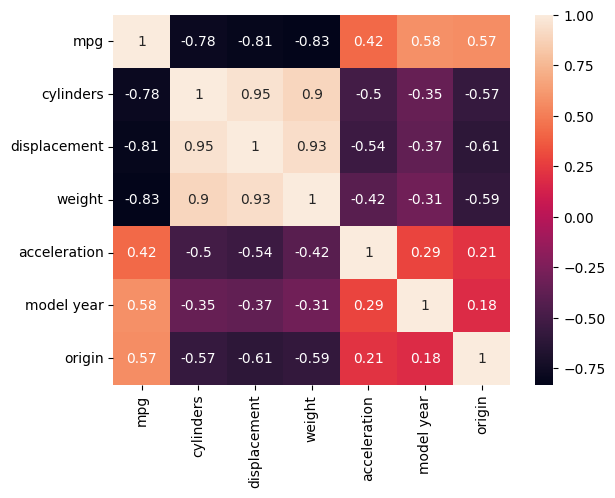

In [11]:
df_num = df_num.astype(float)

sns.heatmap(df_num.corr(), annot=True)

In [12]:
feature_cols = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model year',
]
X = df[feature_cols]

y = df['mpg']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state=42)

In [15]:
X_train['horsepower'] = pd.to_numeric(X_train['horsepower'], errors='coerce')
X_test['horsepower'] = pd.to_numeric(X_test['horsepower'], errors='coerce')

print(X_train['horsepower'].isnull().sum())
print(X_test['horsepower'].isnull().sum())

0
0


In [16]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
print(X_train.dtypes)
print(X_train.isnull().sum())

cylinders         Int64
displacement    Float64
horsepower        Int64
weight            Int64
acceleration    Float64
model year        Int64
dtype: object
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
dtype: int64


In [18]:
y_pred = model.predict(X_test)